<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Advanced_NLP_Module_2_Positional_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to **Module 2** of **[Course 3: Advanced NLP — Large Language Models](kaggle.com/learn-guide/advanced-nlp)**!

In **[Module 1: The Attention Revolution](https://www.kaggle.com/code/arminnorouzig/advanced-nlp-attention-revolution)**, we built a self-attention mechanism that reads every word in a sequence in parallel. This was a major upgrade over the sequential LSTM from Course 2 — but it introduced a surprising new problem. Because self-attention processes all words simultaneously, it has absolutely no idea which word came first. Shuffle the words in a sentence, and the attention scores do not change at all. In this module, we fix that by injecting a mathematical sense of *position* directly into our word representations — using nothing but sine and cosine functions. Let's dive in!

# Introduction

To understand the problem, consider these two very different sentences:

1. *"The dog bit the man."*
2. *"The man bit the dog."*

Same words. Completely opposite meanings. A model that ignores word order cannot distinguish them at all.

Let's prove this mathematically. Suppose we have word embeddings for two positions and we swap them before computing attention. Because the attention formula treats every position equally — it just computes dot products between all pairs — the resulting attention scores are identical regardless of order. There is nothing in the math that penalizes or even notices the swap.

Here is a concrete demonstration:

In [1]:
import numpy as np

def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

def attention_scores(X):
    """Compute raw self-attention scores for an embedding matrix X."""
    d_k = X.shape[-1]
    scores = X @ X.T / np.sqrt(d_k)
    return softmax(scores)

np.random.seed(7)
# Imagine two word embeddings: embedding for position 0 and position 1
emb_word_A = np.array([0.9, 0.1, 0.4, 0.7])   # e.g. "dog"
emb_word_B = np.array([0.2, 0.8, 0.6, 0.3])   # e.g. "man"

# Original order: [dog, man]
X_original = np.stack([emb_word_A, emb_word_B])
# Swapped order: [man, dog]
X_swapped  = np.stack([emb_word_B, emb_word_A])

scores_original = attention_scores(X_original)
scores_swapped  = attention_scores(X_swapped)

print("Attention weights — original order [dog, man]:")
print(scores_original.round(4))
print("\nAttention weights — swapped order [man, dog]:")
print(scores_swapped.round(4))
print("\nAre they the same? (just row/column permuted):", np.allclose(scores_original, scores_swapped[[1,0],:][:,[1,0]]))

Attention weights — original order [dog, man]:
[[0.5939 0.4061]
 [0.4477 0.5523]]

Attention weights — swapped order [man, dog]:
[[0.5523 0.4477]
 [0.4061 0.5939]]

Are they the same? (just row/column permuted): True


**Code Explanation:**
* **`X @ X.T`**: In this simplified example, we use the same matrix as both the Query and the Key (a common simplification for demonstration). The dot product of each row with every other row produces the raw attention score — measuring how similar two embeddings are.
* **`scores_original` vs `scores_swapped`**: Notice that when we swap the order of the two embeddings, the attention score matrix is simply a row-and-column permutation of the original. The *relative* scores between the two words are identical — the model literally cannot tell them apart. This is the position-blindness problem.
* **`np.allclose(...)`**: This confirms mathematically that swapping positions produces the exact same attention pattern. The model cannot distinguish `[dog, man]` from `[man, dog]` using attention alone.

# The Mathematics of Positional Encoding

The elegant solution, introduced in the original *[Attention Is All You Need](https://arxiv.org/abs/1706.03762)* paper (Vaswani et al., 2017), is to **add** a fixed positional signal to every word embedding before the attention step. This signal is computed using sine and cosine functions at different frequencies:

$$PE_{(pos,\, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Where:
* $pos$ is the position of the word in the sequence (0, 1, 2, …)
* $i$ is the index of the dimension pair (0, 1, 2, …, $d_{model}/2 - 1$)
* $d_{model}$ is the embedding dimension

**Why sine and cosine?** Three key properties make them ideal:

1. **Bounded:** Both functions always output values in $[-1, 1]$, so adding them to the word embeddings never causes values to explode.
2. **Unique per position:** Every position $pos$ produces a unique vector of sine and cosine values — the model can distinguish any two positions.
3. **Generalizes beyond training length:** Unlike a learned positional embedding table, the formula can be evaluated for any position, including lengths never seen during training.

Crucially, this encoding has **zero trainable parameters**. We compute it once and add it directly to the embedding. The model then learns, through the weight matrices $W^Q$, $W^K$, $W^V$, to use these positional signals to understand word order.

## Architecture Diagram

The diagram below shows how positional encoding slots into the data flow. The key insight is that it is a pure **addition** — the same shape as the embedding, no extra weights, no extra layers in the trainable sense.

```mermaid
graph LR
    A["Token IDs<br/>(batch, seq_len)"] --> B["Embedding Layer<br/>(learnable weights)"]
    B --> C["Word Embeddings<br/>(batch, seq_len, d_model)"]
    PE["Positional Encoding<br/>(fixed sine/cosine, no weights)"] --> D
    C --> D["+  Addition"]
    D --> E["Position-Aware Vectors<br/>(batch, seq_len, d_model)"]
    E --> F["Multi-Head Self-Attention"]
    F --> G["Context-Aware Output"]
```

Compare this to Module 1's diagram: the only change is the `+ Positional Encoding` box inserted between the embedding and the attention layer. The rest of the pipeline is identical.

# Implementing the PositionalEncoding Layer

We will implement positional encoding as a subclassed `tf.keras.layers.Layer`. This lets us drop it into any Keras model just like `LSTM` or `Dense` — a clean, reusable building block we will carry forward into Modules 3 and 4.

In [2]:
import tensorflow as tf
import numpy as np

class PositionalEncoding(tf.keras.layers.Layer):
    """
    Adds fixed sine/cosine positional signals to word embeddings.
    Has zero trainable parameters.
    """

    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model
        # Pre-compute the full PE matrix once at construction time
        self.pe = self._build_pe_matrix(max_len, d_model)  # (1, max_len, d_model)

    def _build_pe_matrix(self, max_len, d_model):
        """Compute the positional encoding matrix using vectorized NumPy."""
        positions = np.arange(max_len)[:, np.newaxis]          # (max_len, 1)
        i_indices  = np.arange(d_model // 2)[np.newaxis, :]    # (1, d_model/2)

        # Denominator: 10000^(2i / d_model)
        denominator = np.power(10000.0, (2 * i_indices) / d_model)
        angles = positions / denominator                        # (max_len, d_model/2)

        # Interleave: even dimensions → sin, odd dimensions → cos
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angles)
        pe[:, 1::2] = np.cos(angles)

        return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)  # (1, max_len, d_model)

    def call(self, x):
        """Add positional encoding to the input embedding tensor."""
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]

    def get_config(self):
        config = super().get_config()
        config.update({"max_len": self.max_len, "d_model": self.d_model})
        return config


# Quick sanity check
pe_layer = PositionalEncoding(max_len=10, d_model=8)
dummy_emb = tf.zeros((1, 10, 8))          # batch=1, seq_len=10, d_model=8
pe_output  = pe_layer(dummy_emb)
print("Input shape:  ", dummy_emb.shape)
print("Output shape: ", pe_output.shape)
print("Output is no longer all zeros (PE added):")
print(pe_output[0, :3, :].numpy().round(4))  # First 3 positions, all 8 dims

Input shape:   (1, 10, 8)
Output shape:  (1, 10, 8)
Output is no longer all zeros (PE added):
[[ 0.      1.      0.      1.      0.      1.      0.      1.    ]
 [ 0.8415  0.5403  0.0998  0.995   0.01    1.      0.001   1.    ]
 [ 0.9093 -0.4161  0.1987  0.9801  0.02    0.9998  0.002   1.    ]]


**Code Explanation:**

* **`super().__init__`**`(**kwargs)`: Standard Keras layer initialization. The `**kwargs` passes any extra arguments (like `name=`) up to the parent class.
* **`_build_pe_matrix`**: We pre-compute the entire PE matrix at construction time and store it as a constant tensor. This avoids recomputing it on every forward pass — an important efficiency detail.
* **`positions` and `i_indices`**: We use broadcasting to compute all `(pos, i)` angle values at once with a single NumPy operation, rather than looping over positions. `positions` has shape `(max_len, 1)` and `i_indices` has shape `(1, d_model/2)` — broadcasting fills the `(max_len, d_model/2)` matrix automatically.
* **`pe[:, 0::2]` and `pe[:, 1::2]`**: Even-indexed dimensions get $\sin$, odd-indexed get $\cos$. The `0::2` slice means "start at 0, step by 2" — a clean Python way to select every other column.
* **`pe[np.newaxis, :, :]`**: We add a leading batch dimension of size 1, giving shape `(1, max_len, d_model)`. When we add this to an input of shape `(batch, seq_len, d_model)`, NumPy/TensorFlow broadcasting automatically repeats the PE across the batch.


# Building a Model with Positional Encoding

Now let's plug our `PositionalEncoding` layer into a complete Keras model. We will use a **learned `Embedding` layer** (which maps integer token IDs to dense vectors) followed immediately by positional encoding. This is the exact setup used in real Transformer architectures — the model jointly learns what each word means *and* uses the fixed PE signals to understand where each word sits in the sequence.

For the tiny illustration run, we tokenize the same Sentiment Dataset from Course 2 into integer token IDs using TensorFlow's `TextVectorization` layer.

In [3]:
from tensorflow.keras import layers, Model

def build_pe_classifier(vocab_size, max_len, d_model, num_heads):
    """
    Sentiment classifier: Embedding → PositionalEncoding → MultiHeadAttention → Dense.

    Args:
        vocab_size : number of unique tokens in the vocabulary
        max_len    : maximum sequence length (tokens)
        d_model    : embedding dimension (also the attention model dimension)
        num_heads  : number of parallel attention heads
    """
    inputs = layers.Input(shape=(max_len,), dtype=tf.int32, name="token_ids")

    # 1. Learnable word embedding (maps integer IDs to dense vectors)
    x = layers.Embedding(vocab_size, d_model, name="word_embedding")(inputs)

    # 2. Add fixed positional encoding — no extra trainable weights
    x = PositionalEncoding(max_len=max_len, d_model=d_model, name="positional_encoding")(x)

    # 3. Self-attention
    x = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        name="self_attention"
    )(x, x)

    # 4. Collapse sequence dimension
    x = layers.GlobalAveragePooling1D(name="sequence_avg")(x)

    # 5. Binary classification
    outputs = layers.Dense(1, activation='sigmoid', name="sentiment_output")(x)

    return Model(inputs=inputs, outputs=outputs, name="PE_Attention_Classifier")


# Build with the tiny illustration dimensions from the issue
VOCAB_SIZE = 5000
MAX_LEN    = 60
D_MODEL    = 32
NUM_HEADS  = 2

model = build_pe_classifier(VOCAB_SIZE, MAX_LEN, D_MODEL, NUM_HEADS)
model.summary()

Model: "PE_Attention_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 60, 32)    │    160,000 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 60, 32)    │          0 │ word_embedding[0… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 60, 32)    │      4,224 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_avg        │ (None, 32)        │          0 │ self_attention[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │         33 │ sequence_avg[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 164,257 (641.63 KB)

 Trainable params: 164,257 (641.63 KB)

 Non-trainable params: 0 (0.00 B)

**Code Explanation:**
* **`layers.Input(shape=(max_len,), dtype=tf.int32)`**: Unlike Module 1 where we passed pre-embedded 250-dimensional vectors, here our input is a sequence of **integer token IDs** — one integer per word. The `Embedding` layer converts them to dense vectors internally during the forward pass.
* **`layers.Embedding(vocab_size, d_model)`**: A lookup table with `vocab_size × d_model` trainable parameters. For token ID `42`, it returns row 42 of this table. The model learns to adjust these rows to capture meaning during training — similar to how Wiki-words embeddings captured meaning from Wikipedia, but trained from scratch on our specific task.
* **`PositionalEncoding(...)`**: Our custom layer from above, added directly after the embedding. The model summary will show `0` trainable parameters for this layer — confirming it is fixed.
* **`MultiHeadAttention(num_heads=2, key_dim=16)`**: With `d_model=32` and 2 heads, each head works in 16-dimensional Q/K/V space. This is small by production standards but perfect for a quick illustration.
* **Parameter count**: Look at the model summary — the `word_embedding` layer has `5000 × 32 = 160,000` parameters, `positional_encoding` has `0`, and the attention layer has a relatively small number. This shows that the embedding is often the largest component in small models.

# Training on a Sample Dataset (Illustration Only)

Let's confirm that our positional encoding model trains end-to-end. We load the same **Sentiment Dataset** from Course 2, tokenize it with TensorFlow's `TextVectorization` layer (which converts raw text into integer token IDs), and train for **5 epochs** on only **200 samples**.

> **Important:** This tiny model (`d_model=32`, `num_heads=2`, 200 samples) will not achieve impressive accuracy. Its purpose is solely to confirm that positional encoding integrates cleanly with a learnable embedding and that the loss decreases over training epochs. In a real deployment you would use a larger `d_model` and the full dataset.

In [4]:
import pandas as pd
import os
import kagglehub

# 1. Load the Sentiment Dataset — same source as Course 2
dataset_path = kagglehub.dataset_download("kinchittrivedi/sentiment-analysis-movie-reviews")

with open(os.path.join(dataset_path, 'positive.txt'), "r", encoding="latin-1") as f:
    positives = [line.strip() for line in f]
with open(os.path.join(dataset_path, 'negative.txt'), "r", encoding="latin-1") as f:
    negatives = [line.strip() for line in f]

df = pd.DataFrame({
    'text':  positives + negatives,
    'label': [1] * len(positives) + [0] * len(negatives)
})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Full dataset: {len(df)} samples")

# 2. Tiny subset: 200 samples only
df_tiny = df.head(200).reset_index(drop=True)
texts_tiny  = df_tiny['text'].tolist()
labels_tiny = df_tiny['label'].tolist()

# 3. Build vocabulary with TextVectorization (fit on full dataset for realistic vocab)
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
vectorizer.adapt(df['text'].tolist())   # fit vocabulary on full dataset
print(f"Vocabulary size: {len(vectorizer.get_vocabulary())}")

# 4. Vectorize the tiny subset into integer token sequences
X_tiny = vectorizer(texts_tiny).numpy()    # (200, MAX_LEN) integer matrix
Y_tiny = np.array(labels_tiny)
print(f"X shape: {X_tiny.shape}  — (samples, seq_len)")
print(f"Y shape: {Y_tiny.shape}")
print(f"Example tokenized sentence (first 10 tokens): {X_tiny[0, :10]}")

100%|██████████| 1.07M/1.07M [00:00<00:00, 103MB/s]

Extracting files...
Full dataset: 5000 samples


Vocabulary size: 5000
X shape: (200, 60)  — (samples, seq_len)
Y shape: (200,)
Example tokenized sentence (first 10 tokens): [ 848 1284    7    5  259  237   22    2   77   75]


**Code Explanation:**
* **`TextVectorization`**: A Keras preprocessing layer that converts raw strings into padded integer sequences. `max_tokens=5000` keeps only the 5,000 most common words. `output_sequence_length=MAX_LEN` pads shorter sentences with zeros and truncates longer ones — the same role that `get_padded_encoded_texts` played in Course 2, but for integer IDs instead of embedding vectors.
* **`vectorizer.adapt(df['text'].tolist())`**: We build the vocabulary on the *full* dataset, not just the 200-sample slice. This ensures the vocabulary covers the full range of words the model might encounter — even though we only train on 200 rows.
* **Integer tokens vs. floating-point embeddings**: In Course 2, `X` had shape `(N, 59, 250)` — already embedded. Here, `X` has shape `(200, 60)` — raw integers. The `Embedding` layer inside our Keras model handles the lookup at training time. This is the standard Transformer input pipeline.

Starting tiny training run (200 samples, 5 epochs)...
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5000 - loss: 0.7028 - val_accuracy: 0.4750 - val_loss: 0.7047
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5125 - loss: 0.6960 - val_accuracy: 0.4750 - val_loss: 0.6959
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5125 - loss: 0.6903 - val_accuracy: 0.6000 - val_loss: 0.6927
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5750 - loss: 0.6920 - val_accuracy: 0.5250 - val_loss: 0.6914
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5437 - loss: 0.6870 - val_accuracy: 0.4750 - val_loss: 0.6952


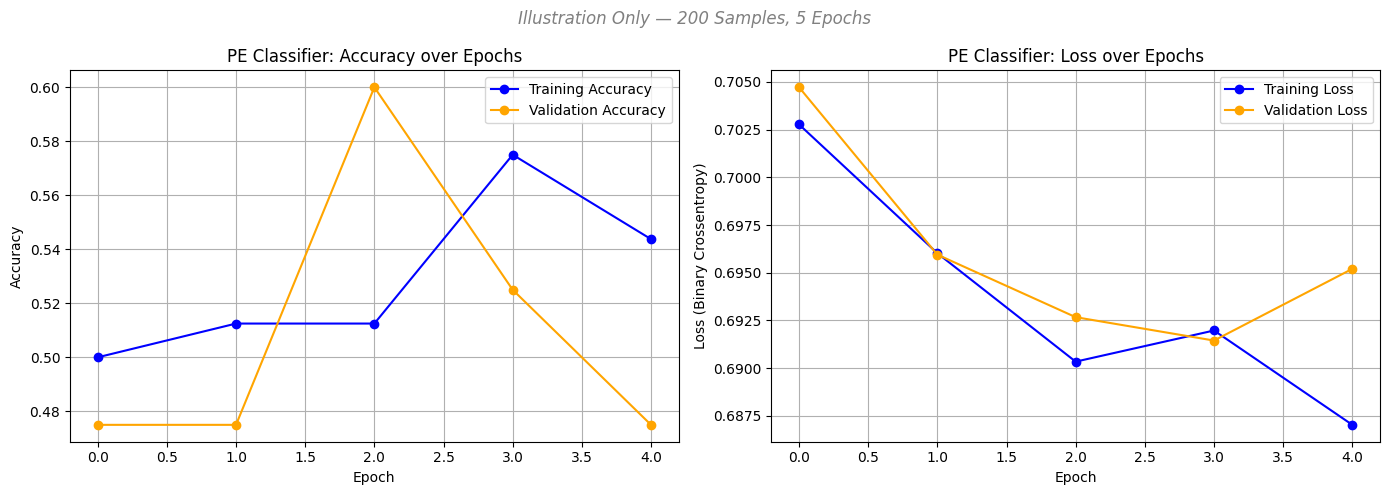


Final training loss:     0.6870
Final training accuracy: 0.5437
Key observation: loss decreased — positional encoding trains successfully!


In [5]:
import matplotlib.pyplot as plt

# Build and compile the tiny illustration model
tiny_model = build_pe_classifier(VOCAB_SIZE, MAX_LEN, D_MODEL, NUM_HEADS)

tiny_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Starting tiny training run (200 samples, 5 epochs)...")
history = tiny_model.fit(
    X_tiny, Y_tiny,
    epochs=5,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Plot learning curves — Course 2 style
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Training Accuracy',   color='blue',   marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('PE Classifier: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Training Loss',   color='blue',   marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('PE Classifier: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Illustration Only — 200 Samples, 5 Epochs', fontstyle='italic', color='gray')
plt.tight_layout()
plt.show()

print(f"\nFinal training loss:     {history.history['loss'][-1]:.4f}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print("Key observation: loss decreased — positional encoding trains successfully!")

**Code Explanation:**
* **`optimizer='adam'`, `loss='binary_crossentropy'`**: Identical settings to every model in Course 2. `adam` adapts the learning rate automatically; `binary_crossentropy` is the mathematically optimal loss for a two-class problem.
* **`batch_size=16`**: With only 200 samples, we use smaller batches than Course 2's 32 to ensure the model sees enough gradient updates per epoch.
* **`validation_split=0.2`**: 40 of our 200 samples are held back for validation — the same 80/20 split used throughout Course 2. With such a small validation set, `val_accuracy` will fluctuate significantly between epochs; this is expected.
* **What to look for**: The training loss should decrease over 5 epochs. This confirms that the positional encoding layer, the embedding layer, and the attention layer all receive valid gradients and update correctly. The absolute accuracy values are not the focus here.

# Visualizing the Positional Encoding Matrix

One of the most beautiful properties of positional encoding is that it creates a visually distinctive pattern. Let's generate a PE matrix for a longer sequence and plot it as a heatmap — you will immediately see the wave-like sine and cosine frequencies that give each position its unique fingerprint.

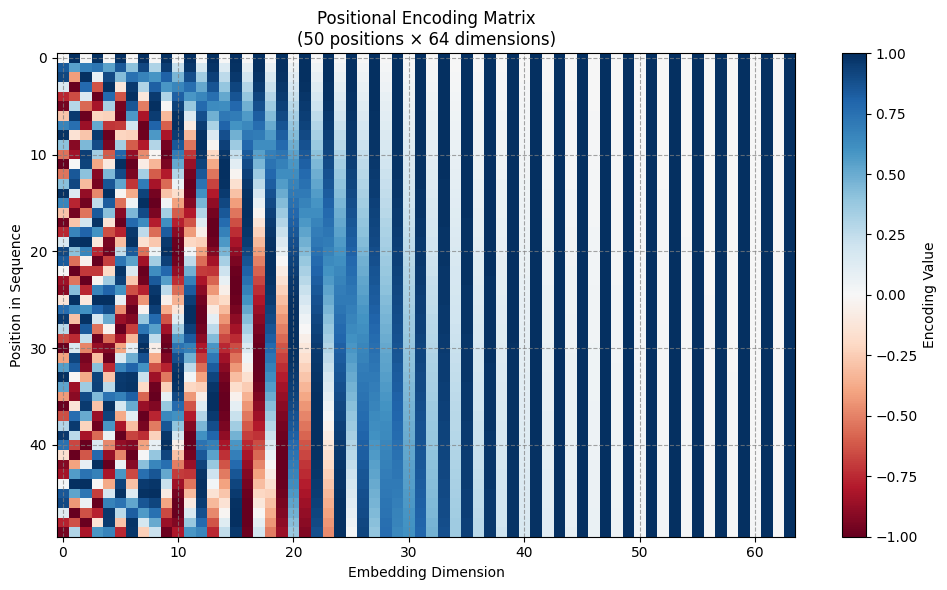

Cosine similarity between adjacent positions (should be high — nearby positions are similar):
  Position  0 ↔  1: 0.9662
  Position  5 ↔  6: 0.9662
  Position 10 ↔ 11: 0.9662
  Position 20 ↔ 21: 0.9662

Cosine similarity between distant positions (should be lower):
  Position  0 ↔ 10: 0.6579
  Position  0 ↔ 25: 0.6292
  Position  0 ↔ 49: 0.4754


In [6]:
# Generate a PE matrix for 50 positions with 64 dimensions for a clear visualization
pe_vis = PositionalEncoding(max_len=50, d_model=64)
dummy_input = tf.zeros((1, 50, 64))
pe_matrix = pe_vis(dummy_input)[0].numpy()  # shape (50, 64)

plt.figure(figsize=(10, 6))
plt.imshow(pe_matrix, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Encoding Value')
plt.title("Positional Encoding Matrix\n(50 positions × 64 dimensions)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position in Sequence")
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.tight_layout()
plt.show()

# Show cosine similarity between adjacent positions — they should be close to each other
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("Cosine similarity between adjacent positions (should be high — nearby positions are similar):")
for pos in [0, 5, 10, 20]:
    sim = cosine_similarity(pe_matrix[pos], pe_matrix[pos + 1])
    print(f"  Position {pos:2d} ↔ {pos+1:2d}: {sim:.4f}")

print("\nCosine similarity between distant positions (should be lower):")
for pair in [(0, 10), (0, 25), (0, 49)]:
    sim = cosine_similarity(pe_matrix[pair[0]], pe_matrix[pair[1]])
    print(f"  Position {pair[0]:2d} ↔ {pair[1]:2d}: {sim:.4f}")

**Code Explanation:**
* **`cmap='RdBu'`**: A diverging colormap where red represents −1, white represents 0, and blue represents 1. This makes the sine/cosine oscillations immediately visible as alternating bands.
* **`vmin=-1, vmax=1`**: Fixed color scale matching the bounded output range of sine and cosine. Every cell in the matrix is guaranteed to fall within this range.
* **`plt.grid(True, linestyle='--', alpha=0.7)`**: The exact grid style from Course 2 plots, applied to the heatmap for consistency.
* **`aspect='auto'`**: Allows matplotlib to stretch the matrix to fill the figure area, rather than forcing a square pixel per cell. With 50 rows and 64 columns, this produces a readable rectangular heatmap.
* **Cosine similarity check**: We verify the key property of positional encoding — **nearby positions should have similar encoding vectors** (high cosine similarity), while **distant positions should diverge** (lower similarity). This is exactly what makes the encodings useful: the model can infer "these two words are close together" from the similarity of their positional signals.

# Conclusion & Next Steps

In this module, we identified and solved the position-blindness problem of self-attention. We proved mathematically that swapping word positions produces identical attention scores, then fixed it by injecting sine and cosine positional signals directly into the word embeddings — with zero extra trainable parameters. We implemented the `PositionalEncoding` layer as a reusable Keras component, plugged it into a complete Embedding → PositionalEncoding → MultiHeadAttention → Dense pipeline, and confirmed the whole model trains correctly on the Sentiment Dataset. The heatmap revealed the beautiful wave-like pattern that gives every position its unique mathematical fingerprint.

We now have two powerful building blocks:
1. **Self-Attention** (Module 1) — reads the full sequence in parallel
2. **Positional Encoding** (this module) — tells the model where each word sits

In **[Module 3: The Encoder & Decoder](https://www.kaggle.com/code/arminnorouzig/advanced-nlp-encoder-decoder)**, we will combine these two ingredients — along with a Feed-Forward Network and residual connections — to build the two core architectural units of the Transformer: the `EncoderLayer` and the `DecoderLayer`.

<script type="module">
  import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';

  // Find ALL generic code blocks
  const blocks = document.querySelectorAll('pre code');

  blocks.forEach((block) => {
      let text = block.textContent.trim();
      let isMermaid = false;
      let diagramCode = text;

      // Case 1: Check if the element or its parent has a mermaid class
      const hasMermaidClass = Array.from(block.classList).some(cls => cls.includes('mermaid')) ||
                             (block.parentElement && Array.from(block.parentElement.classList).some(cls => cls.includes('mermaid')));

      if (hasMermaidClass) {
          isMermaid = true;
      }
      // Case 2: Check if the text literally starts with the word "mermaid"
      else if (text.startsWith('mermaid')) {
          isMermaid = true;
          // Strip out the word "mermaid" and any leading whitespace/newlines
          diagramCode = text.replace(/^mermaid\s*/i, '');
      }

      if (isMermaid) {
          // Create a proper div for Mermaid
          const div = document.createElement('div');
          div.className = 'mermaid';
          div.textContent = diagramCode;

          // Replace the parent <pre> tag with the new div
          const pre = block.parentElement;
          if (pre && pre.tagName === 'PRE') {
              pre.replaceWith(div);
          }
      }
  });

  // Initialize and run the render
  mermaid.initialize({ startOnLoad: false });
  await mermaid.run();
</script>
